# Inspect the Generated Distractor Datasets

In [1]:
import json
import re
import math

import torch
import numpy as np

import matplotlib.pyplot as plt

In [6]:
with open("data/datasets/am/icl/500/distractors.json", "r+") as f:
    data = json.load(f)
    print(f"Loaded dataset of {len(data)} MWPs")

Loaded dataset of 500 MWPs


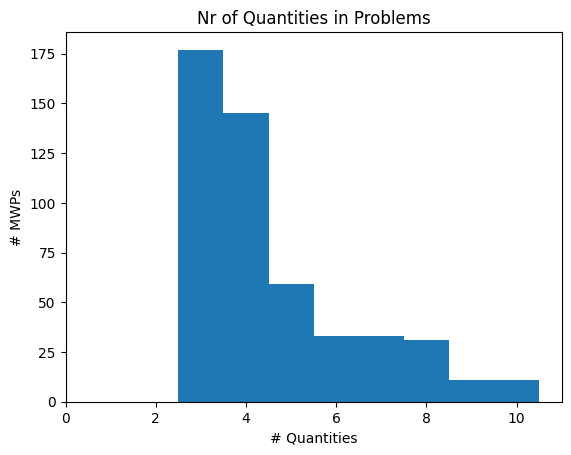

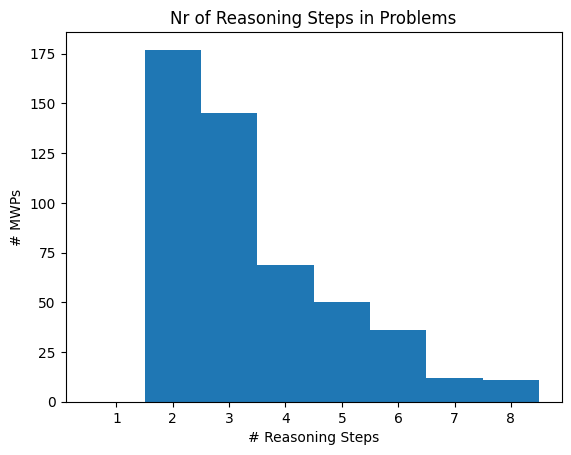

mean-nr-steps: 3.416 \pm 1.5527214817860926


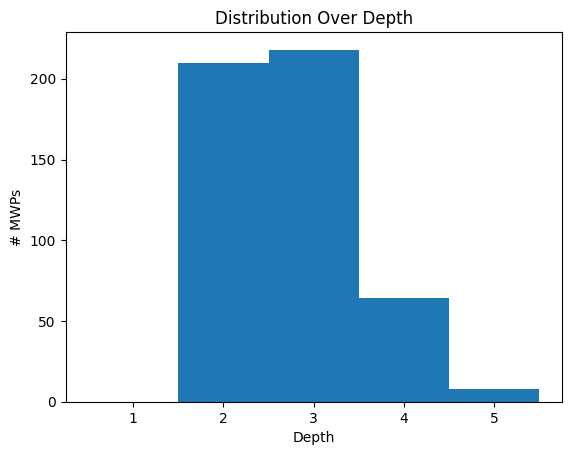

mean-depth: 2.742 \pm 0.7452757878798961


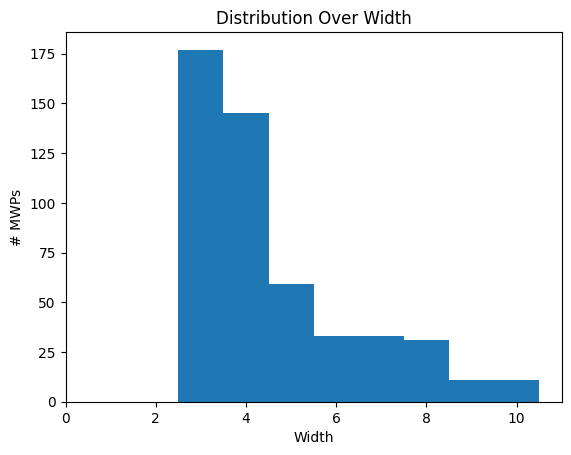

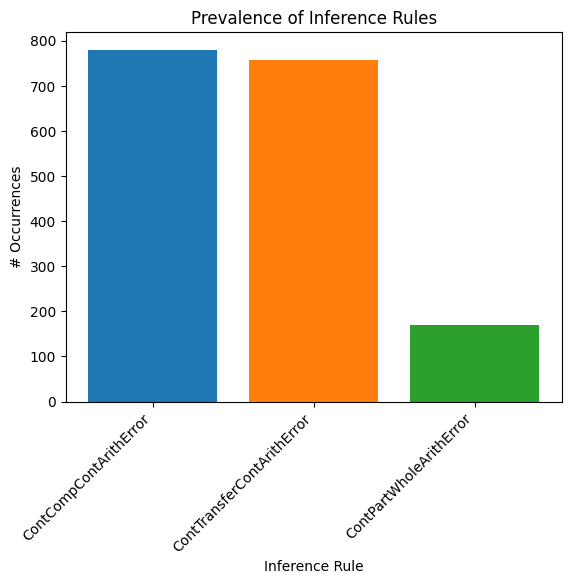

# Problems without Compeq 500/500


In [7]:
# nr of quantities per MWP
quants = []
nr_steps = []
depths = []
widths = []
rule_cnts = {}
nr_problems_without_compeq = 0
for mwp_id in data:
    mwp_data = data[mwp_id]
    
    for num_inst in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][num_inst]
        num_quant = len(num_inst_data["instantiation"])
        quants.append(num_quant)
        break

    steps = len(mwp_data["metadata"]["orig_rules_by_conclusion"])
    nr_steps.append(steps)

    depths.append(mwp_data["metadata"]["depth"])
    widths.append(mwp_data["metadata"]["width"])

    for rule in mwp_data["metadata"]["orig_rules_by_conclusion"].values():
        rule_cnts[rule] = rule_cnts.get(rule, 0) + 1

    if "ContCompCompeqCont" not in mwp_data["metadata"]["orig_rules_by_conclusion"].values():
        nr_problems_without_compeq += 1

plt.title("Nr of Quantities in Problems")
plt.xlabel("# Quantities")
plt.ylabel("# MWPs")
plt.hist(quants, align="left", bins=list(range(1, max(quants)+1)))
plt.show()

plt.title("Nr of Reasoning Steps in Problems")
plt.xlabel("# Reasoning Steps")
plt.ylabel("# MWPs")
plt.hist(nr_steps, align="left", bins=list(range(1, max(nr_steps)+1)))
plt.show()
print(f"mean-nr-steps: {np.mean(nr_steps)} \\pm {np.std(nr_steps)}")

plt.title("Distribution Over Depth")
plt.xlabel("Depth")
plt.ylabel("# MWPs")
plt.hist(depths, align="left", bins=list(range(1, max(depths)+1)))
plt.show()
print(f"mean-depth: {np.mean(depths)} \\pm {np.std(depths)}")

plt.title("Distribution Over Width")
plt.xlabel("Width")
plt.ylabel("# MWPs")
plt.hist(widths, align="left", bins=list(range(1, max(widths)+1)))
plt.show()

plt.title("Prevalence of Inference Rules")
plt.xlabel("Inference Rule")
plt.xticks(rotation=45, ha="right")
plt.ylabel("# Occurrences")
for r,cnt in rule_cnts.items():
    plt.bar(str(r), cnt)
plt.show()

print(f"# Problems without Compeq {nr_problems_without_compeq}/{len(data)}")

# Remove Op Pert

In [2]:
file = "data/datasets/icl/ls500/llama2_7B_I_s3_mwp_hle.json"
with open(file, "r+") as f:
    data = json.load(f)

for mwp_id in data:
    for inst_id in data[mwp_id]["instantiations"]:
        data[mwp_id]["instantiations"][inst_id]["all_op_perturbation_answers"] = None

with open(file, "w+") as f:
    json.dump(data, f)

# Guess Nr of Tokens

In [8]:
from transformers import AutoTokenizer

file = "data/datasets/icl/ls100/llama31_70B_I_s0-5s10_mwp_hle.json"
with open(file, "r+") as f:
    data = json.load(f)

In [9]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

In [12]:
total_input = 0
total_output = 0

shots = "3"
for mwp_id in data:
    for inst_id in data[mwp_id]["instantiations"]:
        if "llm_distractor" in data[mwp_id]["instantiations"][inst_id]:
            distgen_data = data[mwp_id]["instantiations"][inst_id]["llm_distractor"]["3"]
            reason_prompt = distgen_data["reasoning_prompt"]
            reasoning = distgen_data["reasoning"]
            answer_prompt = distgen_data["answer_prompt"]
            answer = distgen_data["answer"]
            
            total_input += len(tokenizer.tokenize(reason_prompt)) + len(tokenizer.tokenize(answer_prompt))
            total_output += len(tokenizer.tokenize(reasoning)) + len(tokenizer.tokenize(answer))



In [20]:
scale_factor = 5 # how much larger will the tested dataset be
input_price_pm = 15
output_price_pm = 60

print(total_input*scale_factor/1_000_000,total_output*scale_factor/1_000_000)
print(total_input*scale_factor/1_000_000*input_price_pm, total_output*scale_factor/1_000_000*output_price_pm)

1.883845 0.172385
28.257675 10.3431


# Inspect Solve and Distgen Answers

In [ ]:
import random

with open("data/datasets/ci/icl/ls500/qwen25_7B_I_s3_mwp.json", "r+") as f:
    data = json.load(f)
    print(f"Loaded dataset of {len(data)} MWPs")

shots = "3"

mwp_inst_ids = []
for mwp_id in data:
    mwp_data = data[mwp_id]
    
    for inst_id in mwp_data["instantiations"]:
        num_inst_data = mwp_data["instantiations"][inst_id]

        if "llm_answer" in num_inst_data and "llm_distractor" in num_inst_data:
            mwp_inst_ids.append((mwp_id, inst_id))

print("Solve")
for i, (mwp_id, inst_id) in enumerate(random.choices(mwp_inst_ids, k=25)):
    num_inst_data = data[mwp_id]["instantiations"][inst_id]
    print(str(i) + "-"*30)
    print(num_inst_data["llm_answer"][shots]["reasoning"])


In [ ]:
print("Distgen")
for i, (mwp_id, inst_id) in enumerate(random.choices(mwp_inst_ids, k=25)):
    print(str(i) + "-"*30)
    num_inst_data = data[mwp_id]["instantiations"][inst_id]
    print(num_inst_data["llm_distractor"][shots]["reasoning"])
    print(num_inst_data["llm_distractor"][shots]["answer"])
    print([a["answer"] for a in num_inst_data["misconception_answers"]])